<a href="https://colab.research.google.com/github/shubhanagrawal/Machine-Learning-and-Data-Analysis/blob/main/inflation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [5]:
file_path = Path("/content/Inflation(13-25).csv")


data=pd.read_csv(file_path)

In [7]:
data

,Month,Commodity Description,Provisional / Final,Rural Index,Rural Inflation,Urban Index,Urban Inflation,Combined Index,Combined Inflation
0,Jan-25,A) General Index,Final,195.9,4.59,190.6,3.87,193.4,4.26
1,Jan-25,A.1) Food and beverages,Final,198.8,5.91,204.6,5.36,200.9,5.68
2,Jan-25,A.1.1) Cereals and products,Final,199.8,6.56,197.5,5.56,199.1,6.24
3,Jan-25,A.1.2) Meat and fish,Final,220.9,5.24,230.8,5.20,224.4,5.25
4,Jan-25,A.1.3) Egg,Final,206.0,0.59,210.8,2.28,207.9,1.27
...,...,...,...,...,...,...,...,...,...
3585,Jan-14,A.6.3) Transport and communication,Final,110.5,6.97,110.8,7.36,110.7,7.27
3586,Jan-14,A.6.4) Recreation and amusement,Final,109.6,6.00,109.8,6.71,109.7,6.40
3587,Jan-14,A.6.5) Education,Final,111.8,7.71,111.5,7.73,111.6,7.72
3588,Jan-14,A.6.6) Personal Care and Effects,Final,108.3,3.44,108.0,3.55,108.2,3.54


In [6]:
data.drop(columns=['Provisional / Final'], inplace=True)

In [7]:
data.dtypes
data['Date']= pd.to_datetime(data['Month'], format='%b-%y')

In [8]:
import pandas as pd

# # Create a DataFrame with a datetime column
# df = pd.DataFrame({'date': pd.to_datetime(['2023-01-15', '2023-04-20', '2023-07-10', '2023-10-05'])})

# Extract the quarter
data['quarter'] = data['Date'].dt.quarter

print(data)


       Month               Commodity Description  Rural Index  \
0     Jan-25                    A) General Index        195.9   
1     Jan-25             A.1) Food and beverages        198.8   
2     Jan-25         A.1.1) Cereals and products        199.8   
3     Jan-25                A.1.2) Meat and fish        220.9   
4     Jan-25                          A.1.3) Egg        206.0   
...      ...                                 ...          ...   
3585  Jan-14  A.6.3) Transport and communication        110.5   
3586  Jan-14     A.6.4) Recreation and amusement        109.6   
3587  Jan-14                    A.6.5) Education        111.8   
3588  Jan-14    A.6.6) Personal Care and Effects        108.3   
3589  Jan-14        B) Consumer Food Price Index        115.9   

      Rural Inflation  Urban Index  Urban Inflation  Combined Index  \
0                4.59        190.6             3.87           193.4   
1                5.91        204.6             5.36           200.9   
2     

In [9]:
data['Year'] = data['Date'].dt.year

data['quarterly_avg_inflation'] = data.groupby(['Year', 'quarter'])['Combined Inflation'].transform('mean')

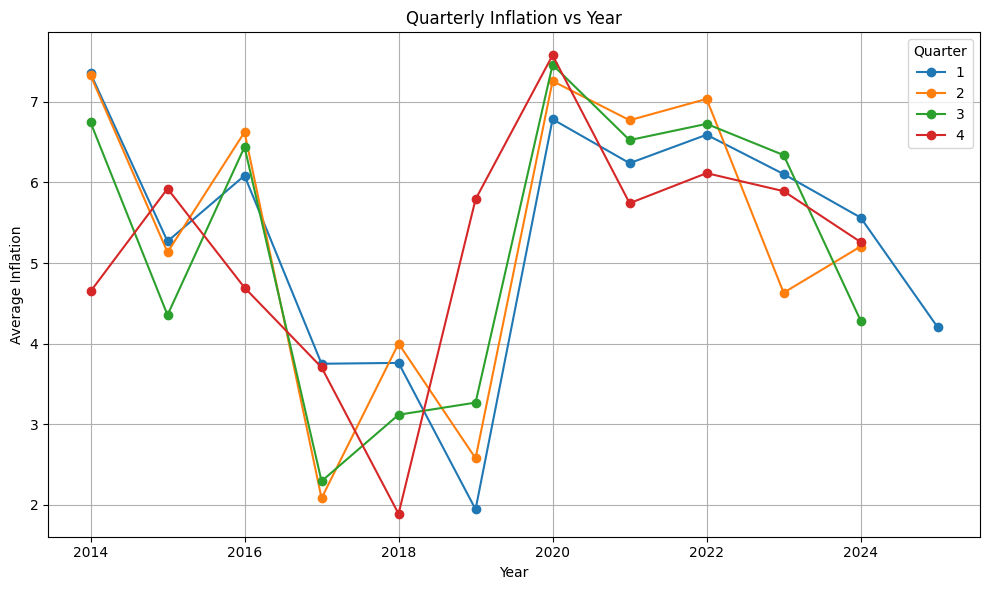

In [10]:
import matplotlib.pyplot as plt

# Ensure 'quarter' column exists
data['quarter'] = data['Date'].dt.quarter

# Group by Year and Quarter
quarterly_avg = data.groupby(['Year', 'quarter'])['Combined Inflation'].mean().unstack()

# Plot
quarterly_avg.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Quarterly Inflation vs Year')
plt.xlabel('Year')
plt.ylabel('Average Inflation')
plt.legend(title='Quarter')
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
from sklearn.model_selection import train_test_split

X=data['Year']
y=data['quarterly_avg_inflation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape the input data for LSTM
# X_train and X_test are currently pandas Series (1D)
# LSTM expects input shape (samples, timesteps, features)
# We will reshape to (samples, 1, 1) where 1 timestep and 1 feature
X_train_reshaped = X_train.values.reshape((X_train.shape[0], 1, 1))
X_test_reshaped = X_test.values.reshape((X_test.shape[0], 1, 1))


model = Sequential()
# Use the reshaped X_train to define the input_shape
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler # Ensure this is imported
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Reshape the input data for LSTM
# X_train and X_test are currently pandas Series (1D)
# LSTM expects input shape (samples, timesteps, features)
# We will reshape to (samples, 1, 1) where 1 timestep and 1 feature
X_train_reshaped = X_train.values.reshape((X_train.shape[0], 1, 1))
X_test_reshaped = X_test.values.reshape((X_test.shape[0], 1, 1))


model = Sequential()
# Use the reshaped X_train to define the input_shape
model.add(LSTM(units=128, return_sequences=True, input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=128))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Instantiate and fit the scaler
# Reshape y_train as it's currently a Series and fit_transform expects 2D array
scaler = MinMaxScaler()
y_train_scaled = scaler.fit_transform(y_train.values.reshape(-1, 1))

# Fit the model using the scaled training data
# Note: Since X is Year, it might not need scaling depending on the model's requirements.
# For LSTM with year as input, it's generally fine not to scale year directly,
# but the target variable (inflation) should be scaled.
history = model.fit(X_train_reshaped, y_train_scaled, epochs=100, batch_size=32, validation_split=0.1)


# Predict using the reshaped test data
predictions = model.predict(X_test_reshaped)

# Inverse transform the predictions and y_test using the fitted scaler
predictions = scaler.inverse_transform(predictions).flatten()
y_test = scaler.inverse_transform(y_test.values.reshape(-1,1)).flatten() # Reshape y_test before inverse transforming

rmse = np.sqrt(np.mean((y_test - predictions)**2))
print(f'RMSE: {rmse:.2f}')

Epoch 1/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.1654 - val_loss: 0.0763
Epoch 2/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0868 - val_loss: 0.0757
Epoch 3/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0850 - val_loss: 0.0770
Epoch 4/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0845 - val_loss: 0.0758
Epoch 5/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0868 - val_loss: 0.0764
Epoch 6/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0854 - val_loss: 0.0767
Epoch 7/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0842 - val_loss: 0.0781
Epoch 8/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0836 - val_loss: 0.0767
Epoch 9/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0857 - val_loss: 0.0789
Epoch 10/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0812 - val_loss: 0.0769
Epoch 11/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0875 - val_loss: 0.0790
Epoch 12/100
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.

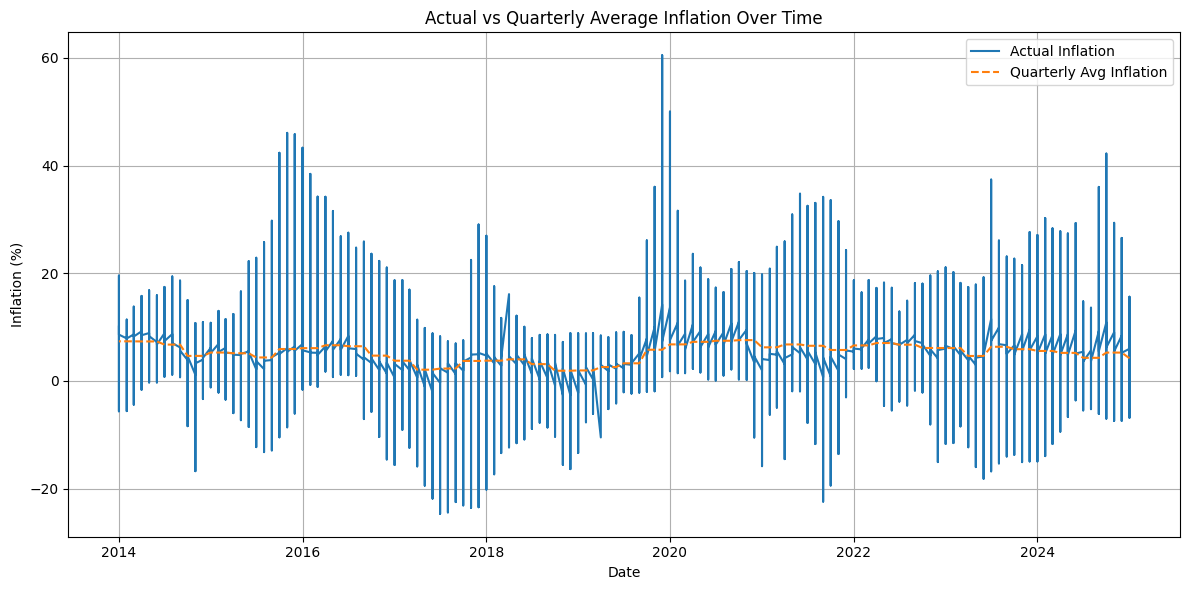

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot actual inflation values
plt.plot(data['Date'], data['Combined Inflation'], label='Actual Inflation')

# Plot predicted or quarterly average inflation
# Use the appropriate column based on your use case:
#   - If using predictions from ML model, replace below with that column.
#   - If visualizing quarterly average, use 'quarterly_avg_inflation'

plt.plot(data['Date'], data['quarterly_avg_inflation'], label='Quarterly Avg Inflation', linestyle='--')

# Customize plot
plt.title('Actual vs Quarterly Average Inflation Over Time')
plt.xlabel('Date')
plt.ylabel('Inflation (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:


# Python
import pandas as pd
from prophet import Prophet

In [18]:

# Python
m = Prophet()
data['y']=data['quarterly_avg_inflation']
data['ds']=data['Date']
m.fit(data)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8d68cvlu/0a9w1bga.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp8d68cvlu/7am048x1.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=48088', 'data', 'file=/tmp/tmp8d68cvlu/0a9w1bga.json', 'init=/tmp/tmp8d68cvlu/7am048x1.json', 'output', 'file=/tmp/tmp8d68cvlu/prophet_modelagjqts03/prophet_model-20250624132948.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
13:29:48 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
13:29:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [19]:

# Python
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
493,2025-12-28
494,2025-12-29
495,2025-12-30
496,2025-12-31
497,2026-01-01


In [20]:
1
2
3
4

# Python
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
493,2025-12-28,6.808056,4.808519,8.918279
494,2025-12-29,6.013192,4.171694,8.126308
495,2025-12-30,5.228242,3.282826,7.385207
496,2025-12-31,4.467006,2.638184,6.580722
497,2026-01-01,3.742526,1.948592,5.958649


In [25]:
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2014-01-01,7.900598,7.185947,8.327455,7.900598,7.900598,-0.163936,-0.163936,-0.163936,-0.163936,-0.163936,-0.163936,0.0,0.0,0.0,7.736663
1,2014-02-01,7.664012,7.022068,8.240540,7.664012,7.664012,-0.051604,-0.051604,-0.051604,-0.051604,-0.051604,-0.051604,0.0,0.0,0.0,7.612409
2,2014-03-01,7.450322,6.834484,8.034453,7.450322,7.450322,-0.025118,-0.025118,-0.025118,-0.025118,-0.025118,-0.025118,0.0,0.0,0.0,7.425204
3,2014-04-01,7.213736,6.443342,7.698341,7.213736,7.213736,-0.105629,-0.105629,-0.105629,-0.105629,-0.105629,-0.105629,0.0,0.0,0.0,7.108107
4,2014-05-01,6.984782,6.301817,7.524127,6.984782,6.984782,-0.084229,-0.084229,-0.084229,-0.084229,-0.084229,-0.084229,0.0,0.0,0.0,6.900552
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
493,2025-12-28,3.914794,4.808519,8.918279,2.251890,6.009958,2.893262,2.893262,2.893262,2.893262,2.893262,2.893262,0.0,0.0,0.0,6.808056
494,2025-12-29,3.912711,4.171694,8.126308,2.246824,6.009453,2.100481,2.100481,2.100481,2.100481,2.100481,2.100481,0.0,0.0,0.0,6.013192
495,2025-12-30,3.910628,3.282826,7.385207,2.233528,6.024378,1.317614,1.317614,1.317614,1.317614,1.317614,1.317614,0.0,0.0,0.0,5.228242
496,2025-12-31,3.908545,2.638184,6.580722,2.208472,6.042875,0.558461,0.558461,0.558461,0.558461,0.558461,0.558461,0.0,0.0,0.0,4.467006


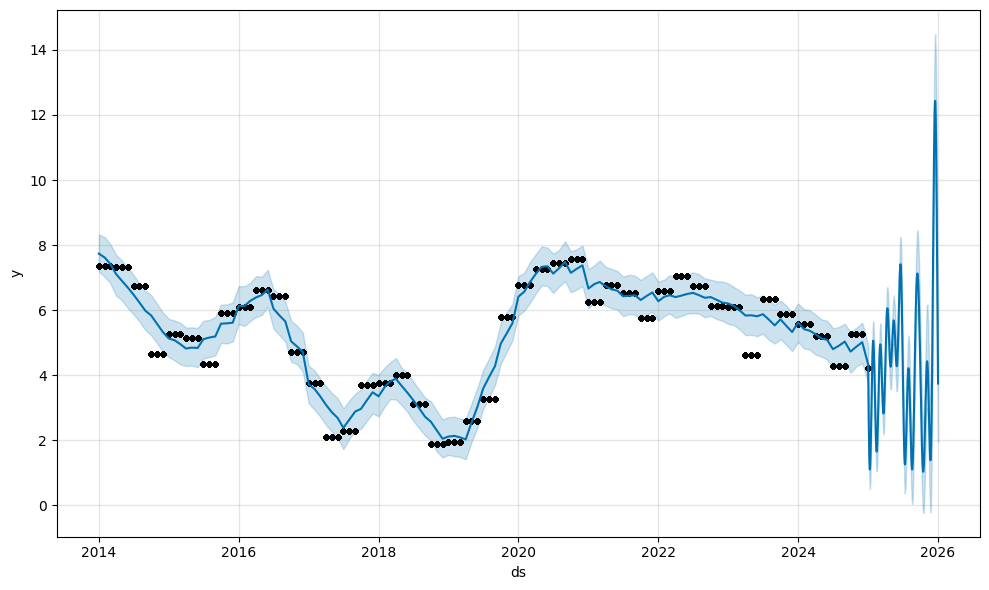

In [21]:
1
2
3

# Python
fig1 = m.plot(forecast)

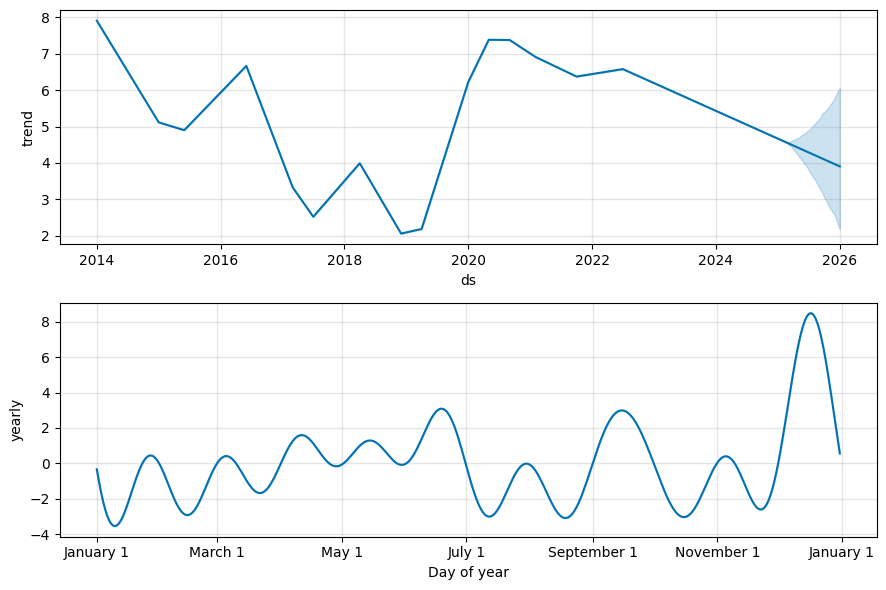

In [22]:
1
2
3

# Python
fig2 = m.plot_components(forecast)

In [23]:
1
2
3
4
5

# Python
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

In [24]:
1
2
3

# Python
plot_components_plotly(m, forecast)

/usr/local/lib/python3.11/dist-packages/plotly/io/_json.py:560: UserWarning:

Discarding nonzero nanoseconds in conversion.

